# 03 — Player Similarity: K-Means Clustering + PCA

Clusters PL 2015/16 outfield players into play-style archetypes, using the per-90 event metrics
built in Session S5 (`src/similarity.py`).

**Clustering is done separately per position group** (Defender / Midfielder / Forward), not all
together. Clustering everyone at once would mostly just rediscover position itself (defenders
tackle a lot, forwards shoot a lot) rather than finding meaningful sub-styles *within* a position
— which is the actually useful output for a recruitment tool ("find another presser like this one,
among forwards").

Unlike the xG model (S2-S4), there's no `is_goal` label to check a cluster against. "Is this a good
clustering" is judged by: does inertia stop dropping sharply past some K (elbow method), and —
more importantly for football — do the resulting groups read as sensible playing styles to someone
who knows the league.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd

from src.similarity import (
    PER90_FEATURE_COLUMNS, scale_features, compute_elbow_scores, fit_kmeans,
    profile_clusters, run_pca,
)
from src.visualisation import plot_elbow_curve, plot_pca_clusters

pd.set_option('display.max_columns', 60)

features = pd.read_pickle('../data/player_per90_pl_2015_16.pkl')
features['position_group'].value_counts()

position_group
Defender      118
Midfielder    104
Forward        78
Name: count, dtype: int64

## Elbow method, per position group

Inertia always decreases as K grows — looking for where it stops dropping sharply, not a single
"correct" point.

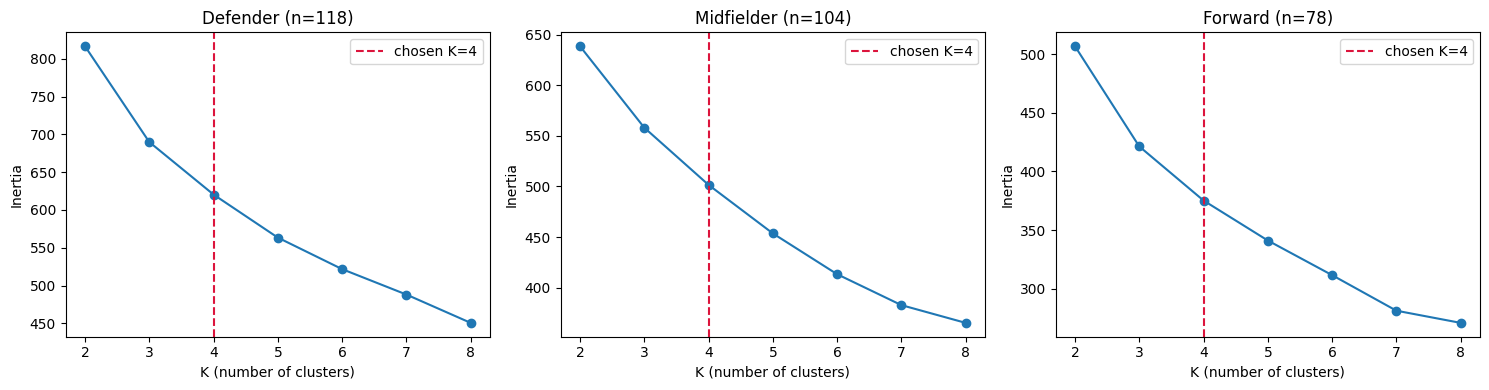

In [2]:
POSITION_GROUPS = ['Defender', 'Midfielder', 'Forward']
CHOSEN_K = {'Defender': 4, 'Midfielder': 4, 'Forward': 4}

groups = {}
for position_group in POSITION_GROUPS:
    subset = features[features['position_group'] == position_group].reset_index(drop=True)
    X_scaled, scaler = scale_features(subset)
    groups[position_group] = {'data': subset, 'X_scaled': X_scaled}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, position_group in zip(axes, POSITION_GROUPS):
    inertias = compute_elbow_scores(groups[position_group]['X_scaled'], k_range=range(2, 9))
    groups[position_group]['inertias'] = inertias
    plot_elbow_curve(inertias, chosen_k=CHOSEN_K[position_group], ax=ax,
                      title=f'{position_group} (n={len(groups[position_group]["data"])})')
fig.tight_layout()
fig.savefig('../outputs/similarity_elbow_curves.png', dpi=150, bbox_inches='tight')

## Fit K-means (K=4 for every group) and profile the clusters

K=4 is used consistently across groups — none of the three elbow curves show one obviously
"correct" K, and 4 balances archetype granularity against group size (e.g. ~20-30 players per
cluster, enough to not be one or two outlier players).

`profile_clusters` gives each cluster's average feature value as a z-score vs. the position
group's own population — this is what's actually read to judge whether the grouping makes
football sense, since there's no accuracy metric to fall back on here.

In [3]:
for position_group in POSITION_GROUPS:
    g = groups[position_group]
    kmeans, labels = fit_kmeans(g['X_scaled'], n_clusters=CHOSEN_K[position_group])
    g['kmeans'] = kmeans
    g['labels'] = labels
    g['data']['cluster'] = labels
    g['profile'] = profile_clusters(g['data'], PER90_FEATURE_COLUMNS, labels)

print('Forward cluster profiles (z-scores vs. all PL 2015/16 forwards):')
groups['Forward']['profile'].round(2)

Forward cluster profiles (z-scores vs. all PL 2015/16 forwards):


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.84,-0.60,-0.01,-0.07,0.16,0.21,-0.29,-0.23,-0.15
1,0.80,0.61,-0.58,-0.28,-0.79,-0.65,-0.54,-0.74,-0.79
2,-0.30,0.01,1.92,1.69,1.91,0.67,-0.33,0.47,-0.08
3,-0.14,-0.24,-0.04,-0.28,0.08,0.38,1.13,1.00,1.24


In [4]:
print('Midfielder cluster profiles:')
display(groups['Midfielder']['profile'].round(2))
print('Defender cluster profiles:')
display(groups['Defender']['profile'].round(2))

Midfielder cluster profiles:


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.24,-0.19,-0.32,-0.36,-0.15,-0.61,-0.53,-0.33,-0.47
1,0.08,0.27,1.69,1.97,0.64,0.20,-0.02,-0.55,-0.57
2,-0.59,-0.61,-0.59,-0.52,0.43,-0.34,0.66,0.85,0.97
3,1.20,1.09,0.51,0.31,-0.85,1.19,-0.41,-0.71,-0.71


Defender cluster profiles:


,non_penalty_goals_p90,shots_p90,key_passes_p90,assists_p90,progressive_passes_p90,dribbles_completed_p90,pressures_p90,interceptions_p90,tackles_p90
cluster,,,,,,,,,
0,-0.45,-0.45,0.23,-0.00,0.16,-0.01,0.85,0.43,0.91
1,0.24,-0.08,-0.63,-0.52,-0.03,-0.57,-0.76,-0.12,-0.72
2,-0.06,0.87,1.23,1.37,-0.13,1.39,0.34,-0.62,0.13
3,5.95,5.28,1.10,1.64,-1.99,4.35,1.00,1.49,0.12


## PCA scatter — 2D view of each position group's clusters

PCA compresses the 9 per-90 features down to 2 components for plotting. Each axis is a blend of
the original features (not a single metric), so this trades away individual-feature
interpretability in exchange for being able to see cluster separation at all — the
`explained_variance_ratio_` below shows how much of the original signal survives that compression.

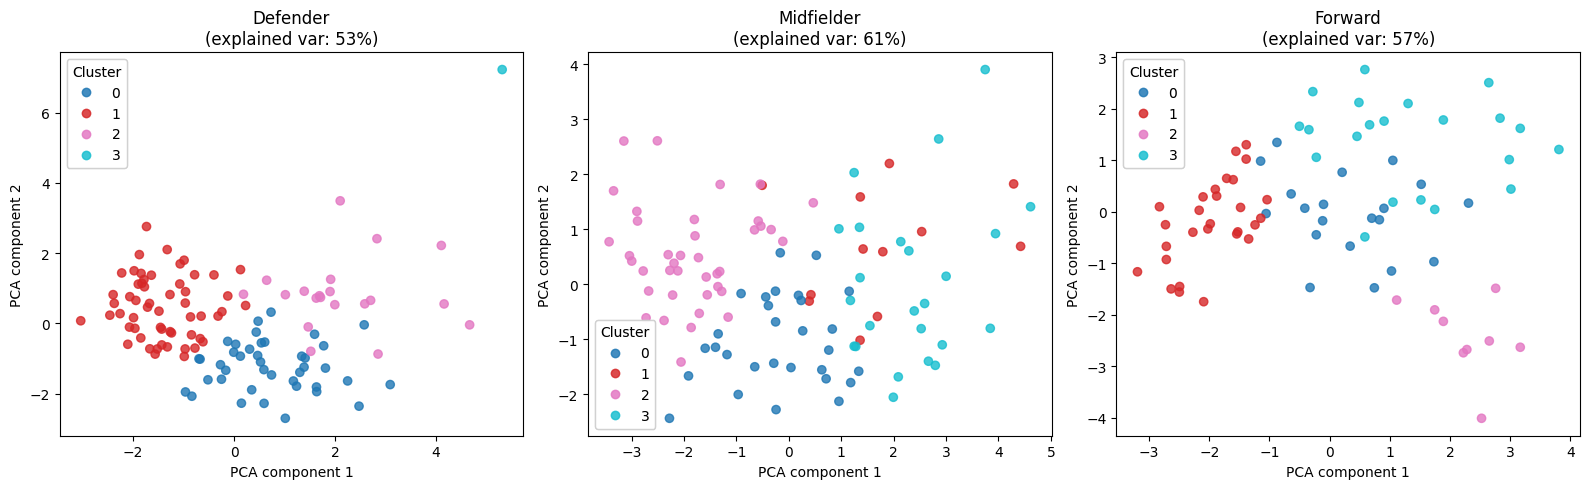

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, position_group in zip(axes, POSITION_GROUPS):
    g = groups[position_group]
    components, pca = run_pca(g['X_scaled'])
    g['pca_components'] = components
    g['pca'] = pca
    plot_pca_clusters(components, g['labels'], ax=ax,
                       title=f'{position_group}\n(explained var: {pca.explained_variance_ratio_.sum():.0%})')
fig.tight_layout()
fig.savefig('../outputs/similarity_pca_clusters.png', dpi=150, bbox_inches='tight')

## Reading the archetypes — who's actually in each cluster

The real test of whether this clustering is useful: do the players grouped together actually play
similar roles? Showing the highest-minutes players per cluster (most data behind their per-90
rates, so the least noisy examples).

In [6]:
for position_group in POSITION_GROUPS:
    data = groups[position_group]['data']
    print(f'=== {position_group} ===')
    for cluster_id in sorted(data['cluster'].unique()):
        top_players = (
            data[data['cluster'] == cluster_id]
            .sort_values('minutes_played', ascending=False)
            .head(5)['player'].tolist()
        )
        print(f'  Cluster {cluster_id} (n={sum(data["cluster"] == cluster_id)}): {", ".join(top_players)}')
    print()

=== Defender ===
  Cluster 0 (n=41): Simon Francis, Ignacio Monreal Eraso, César Azpilicueta Tanco, Daley Blind, Erik Pieters
  Cluster 1 (n=56): Wes Morgan, Toby Alderweireld, Craig Dawson, Ashley Williams, Steve Cook
  Cluster 2 (n=20): Aaron Cresswell, Charlie Daniels, Héctor Bellerín Moruno, Patrick van Aanholt, Robert Brady
  Cluster 3 (n=1): Michail Antonio

=== Midfielder ===
  Cluster 0 (n=29): Andrew Surman, Darren Fletcher, Eric Dier, Mark Noble, Cheikhou Kouyaté
  Cluster 1 (n=12): Mesut Özil, Francesc Fàbregas i Soler, Marc Albrighton, James Philip Milner, Adam David Lallana
  Cluster 2 (n=39): Glenn Whelan, Yann Gérard M''Vila, Idrissa Gana Gueye, Danny Drinkwater, N''Golo Kanté
  Cluster 3 (n=24): Georginio Wijnaldum, Ross Barkley, Riyad Mahrez, Gylfi Þór Sigurðsson, Jason Puncheon

=== Forward ===
  Cluster 0 (n=20): Troy Deeney, Moussa Sissoko, Juan Manuel Mata García, Anthony Martial, Wayne Mark Rooney
  Cluster 1 (n=28): Harry Kane, Jamie Vardy, Romelu Lukaku Menama, 

**Known data-quality wrinkle:** Defender cluster 3 has exactly one player — Michail Antonio, whose
output (z-scores of +5.95 goals/90, +5.28 shots/90) looks nothing like a defender's. He was
primarily a winger that season who filled in defensively in a handful of matches; `position` here
is the season's *modal* per-match position, and that vote evidently landed on a defensive slot
despite his attacking output being the dominant signal. Not a clustering bug — K-means correctly
isolated him as nothing like the other defenders — but a real limitation of "most common position
across the season" as a position-assignment rule for versatile/misused players. Worth a smarter
position-assignment rule (e.g. weight by minutes at each position, or use a player's primary
position from a reference source) if this dataset grows.

## S6 takeaways

- Clustering per position group (rather than all outfield players together) was the right call —
  it surfaces play-style differences *within* a position instead of just rediscovering position
  itself.
- No accuracy metric exists for this the way ROC-AUC exists for the xG model — judgment here comes
  from reading whether the cluster profiles and player groupings make football sense, which they
  do (see the Forward smoke test in `src/similarity.py`'s development: Agüero/Sturridge/Giroud/
  Vardy/Kane/Defoe all landed in the same "pure finisher" cluster).
- PCA's `explained_variance_ratio_` quantifies what the 2D scatter actually shows vs. hides — worth
  reading before trusting a visual cluster gap or overlap at face value.
- Next session (S7): radar charts per player (these per-90 features, presented per-position), PCA
  scatter as a standalone deliverable, and a "players like X" lookup function built on top of these
  same clusters/distances.